<a href="https://colab.research.google.com/github/jiyuutheosum/Machine-Learning/blob/main/Machine_Learning_PIT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name: [ Jalanie Baraocor ] [ Sherri Nicole Tilan ]**

**BSIT - 4R8 - Machine Learning**

# **2. Importing libraries**

In [48]:
# === Cell 1: Install & downloads (run once in Colab) ===
#!pip install -q pyspellchecker
#!pip install -q scikit-learn
#!pip install -q transformers datasets evaluate
#!pip install shap

# === Cell 2: Imports & load dataset ===
import os, re
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from spellchecker import SpellChecker
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression, RidgeClassifier, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.colab import files
import pandas as pd
import io

# NLTK downloads
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# **3. Load Dataset**

In [10]:
print("Upload your dataset (.xlsx or .csv)")
uploaded = files.upload()   # Opens the file picker UI

# Automatically detect the uploaded file name
file_name = next(iter(uploaded))

# Load Excel or CSV
if file_name.endswith(".xlsx"):
    df = pd.read_excel(io.BytesIO(uploaded[file_name]))
elif file_name.endswith(".csv"):
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
else:
    raise ValueError("Unsupported file type. Please upload .xlsx or .csv")

print("\nDataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())

Upload your dataset (.xlsx or .csv)


Saving full-translated-to-eng-dataset.xlsx to full-translated-to-eng-dataset (2).xlsx

Dataset loaded successfully!
Shape: (16175, 3)


,sents,sentiments,topics
0,Full course slides .,2,1
1,"Enthusiastic teaching, close to students.",2,0
2,Attend school with full marks for attendance.,0,1
3,have not yet applied information technology an...,0,0
4,"The teacher teaches well, there are many examp...",2,0


In [31]:
df['label'].value_counts(normalize=True)

,proportion
label,
0,0.9554
1,0.0446


# **4. Label Mapping**

In [13]:
# ---- Auto-detect TEXT column ----
text_candidates = [
    c for c in df.columns
    if any(x in c.lower() for x in ['feedback','comment','text','review','sentiment','response'])
]

if not text_candidates:
    raise ValueError("No text column found. Please rename your text column to something like 'feedback' or 'comment'.")

text_col = text_candidates[0]

# ---- Auto-detect LABEL column ----
label_candidates = [
    c for c in df.columns
    if any(x in c.lower() for x in ['label','sents','rating','class'])
]

# fallback: find binary-like columns
if not label_candidates:
    for c in df.columns:
        if df[c].nunique() == 2 and c != text_col:
            label_candidates.append(c)

if not label_candidates:
    raise ValueError("No label/sentiment column found. Please rename your label column.")

label_col = label_candidates[0]

print(f"Detected text column: {text_col}")
print(f"Detected label column: {label_col}")

# ---- Build the cleaned df ----
df = df[[text_col, label_col]].rename(columns={
    text_col: "text",
    label_col: "original_label"
}).dropna().reset_index(drop=True)

# ---- Sample only 5000 rows ----
SAMPLE_N = 5000
if len(df) > SAMPLE_N:
    df = df.sample(n=SAMPLE_N, random_state=42).reset_index(drop=True)

print("Sampled shape:", df.shape)

# ---- Label Mapping ----
def map_label(val):
    v = str(val).strip().lower()

    positive_words = ['positive','pos','p','1','yes','y','good','happy']
    negative_words = ['negative','neg','n','0','no','bad','angry']

    # String label mapping
    if v in positive_words:
        return 1
    if v in negative_words:
        return 0

    # Numeric label mapping
    if v.isdigit():
        num = int(v)
        if num == 1: return 1
        if num == 0: return 0
        if 1 <= num <= 5:
            return 1 if num >= 3 else 0

    # fallback
    return 1 if 'pos' in v or '1' in v else 0

df["label"] = df["original_label"].apply(map_label)

print("Label distribution:")
print(df["label"].value_counts())


Detected text column: text
Detected label column: original_label
Sampled shape: (5000, 2)
Label distribution:
label
0    4777
1     223
Name: count, dtype: int64


# **5. Data Cleaning**

In [14]:
# === Preprocessing pipeline (cached spellchecker) ===
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
spell = SpellChecker(distance=1)
spell_cache = {}

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'http\S+|www.\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # reduce repeated chars
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    tokens = word_tokenize(text)
    cleaned = []
    for t in tokens:
        if t in stop_words:
            continue
        if len(t) > 2:
            if t in spell_cache:
                t = spell_cache[t]
            else:
                corr = spell.correction(t)
                if corr:
                    spell_cache[t] = corr
                    t = corr
        t = lemmatizer.lemmatize(t)
        cleaned.append(t)
    return " ".join(cleaned)

# Apply
df['clean_text'] = df[text_col].astype(str).map(clean_text)
display(df[['clean_text']].head(8))

,clean_text
0,teacher came place lecture understand
1,advanced knowledge teacher presented still dif...
2,need teacher develop specific set textbook doc...
3,good exercise
4,enthusiastic teacher thank teacher
5,dedicated enthusiastic teacher
6,teacher still bit difficult understand
7,teacher gave score bit tight


# **5. Splitting**

In [15]:
# === split into train/val/test (70/15/15 stratified) ===
X = df['clean_text'].values
y = df['label'].values
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
val_relative = 0.15 / (1 - 0.15)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=val_relative, random_state=42, stratify=y_train_val)
print("Sizes: train", len(X_train), "val", len(X_val), "test", len(X_test))

Sizes: train 3500 val 750 test 750


# **6. Feature Extraction TF-IDF & BoW**

In [16]:
# === feature extraction (TF-IDF & BoW) ===
bow = CountVectorizer(ngram_range=(1,1), max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_val_bow = bow.transform(X_val)
X_test_bow = bow.transform(X_test)

corpus = df['clean_text'].fillna('').tolist()
X_counts = bow.fit_transform(corpus)  # sparse matrix (n_docs x n_features)
print("BoW shape:", X_counts.shape)

# Convert to DataFrame (feature names as columns)
bow_df = pd.DataFrame(X_counts.toarray(), columns=bow.get_feature_names_out())
bow_df.index = df.index  # align indices with original df
bow_df.head()

BoW shape: (5000, 2536)


,00,10,100,10th,11,11doubledot55,12,12doubledot00,13,13h00,...,wzjwz83,wzjwz9,wzjwz92,wzjwz94,xml,year,yes,yet,young,zero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
tfidf = TfidfVectorizer(ngram_range=(1,1), max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

X_tfidf = tfidf.fit_transform(corpus)
print("TF-IDF shape:", X_tfidf.shape)

tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
tfidf_df.index = df.index
tfidf_df.head()

TF-IDF shape: (5000, 2536)


,00,10,100,10th,11,11doubledot55,12,12doubledot00,13,13h00,...,wzjwz83,wzjwz9,wzjwz92,wzjwz94,xml,year,yes,yet,young,zero
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# **Handling Imbalance**

In [44]:
smote = SMOTE(random_state=42)

# APPLY SMOTE (TF-IDF VERSION)
X_train_tfidf_sm, y_train_sm = smote.fit_resample(X_train_tfidf, y_train)
print("TF-IDF SMOTE applied. \nClass counts:",
      {0: sum(y_train_sm==0), 1: sum(y_train_sm==1)})


# APPLY SMOTE (BoW VERSION)
X_train_bow_sm, y_train_bow_sm = smote.fit_resample(X_train_bow, y_train)
print("BoW SMOTE applied. \nClass counts:",
      {0: sum(y_train_bow_sm==0), 1: sum(y_train_bow_sm==1)})

TF-IDF SMOTE applied. 
Class counts: {0: np.int64(3344), 1: np.int64(3344)}
BoW SMOTE applied. 
Class counts: {0: np.int64(3344), 1: np.int64(3344)}


# **7. Train Classical Models**

In [46]:
# TRAINING CLASSICAL MODEL

# Ensure 'models' dict exists and is properly defined (recreate if not)
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "LinearSVC": LinearSVC(max_iter=10000, class_weight='balanced'),
    "MultinomialNB": MultinomialNB(),  # NB does NOT support class weights
    "RidgeClassifier": RidgeClassifier(class_weight='balanced'),
    "PassiveAggressive": PassiveAggressiveClassifier(max_iter=1000, class_weight='balanced')
}

trained_models = {}
val_predictions = {}


# Train using TF-IDF features
print("\nTraining TF-IDF models (with SMOTE)...")
for name, clf in list(models.items()):
    try:
        estimator = clf
        estimator.fit(X_train_tfidf_sm, y_train_sm)
        trained_models[f"{name}_tfidf"] = estimator
        val_predictions[f"{name}_tfidf"] = estimator.predict(X_val_tfidf)
        print(f"  ✅ Trained {name}_tfidf")
    except Exception as e:
        print(f"  ❌ Error training {name}_tfidf:")
        traceback.print_exc()

# Train using BoW features
print("\nTraining BoW models (with SMOTE)...")
for name, clf in list(models.items()):
    try:
        estimator = clf
        estimator.fit(X_train_bow_sm, y_train_bow_sm)
        trained_models[f"{name}_bow"] = estimator
        val_predictions[f"{name}_bow"] = estimator.predict(X_val_bow)
        print(f"  ✅ Trained {name}_bow")
    except Exception as e:
        print(f"  ❌ Error training {name}_bow:")
        traceback.print_exc()

print("\nTraining finished. Trained models:", list(trained_models.keys()))


Training TF-IDF models (with SMOTE)...
  ✅ Trained LogisticRegression_tfidf
  ✅ Trained LinearSVC_tfidf
  ✅ Trained MultinomialNB_tfidf
  ✅ Trained RidgeClassifier_tfidf
  ✅ Trained PassiveAggressive_tfidf

Training BoW models (with SMOTE)...
  ✅ Trained LogisticRegression_bow
  ✅ Trained LinearSVC_bow
  ✅ Trained MultinomialNB_bow
  ✅ Trained RidgeClassifier_bow
  ✅ Trained PassiveAggressive_bow

Training finished. Trained models: ['LogisticRegression_tfidf', 'LinearSVC_tfidf', 'MultinomialNB_tfidf', 'RidgeClassifier_tfidf', 'PassiveAggressive_tfidf', 'LogisticRegression_bow', 'LinearSVC_bow', 'MultinomialNB_bow', 'RidgeClassifier_bow', 'PassiveAggressive_bow']


# **Evaluating classical Models**


=== LogisticRegression_tfidf ===
Accuracy:    0.8520
Precision:   0.1532
Recall:      0.5000
F1 (binary): 0.2345
F1 (macro):  0.5763

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.87      0.92       716
           1       0.15      0.50      0.23        34

    accuracy                           0.85       750
   macro avg       0.56      0.68      0.58       750
weighted avg       0.94      0.85      0.89       750



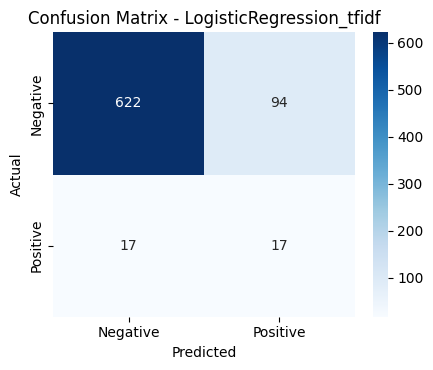


=== LinearSVC_tfidf ===
Accuracy:    0.8840
Precision:   0.1882
Recall:      0.4706
F1 (binary): 0.2689
F1 (macro):  0.6030

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.94       716
           1       0.19      0.47      0.27        34

    accuracy                           0.88       750
   macro avg       0.58      0.69      0.60       750
weighted avg       0.94      0.88      0.91       750



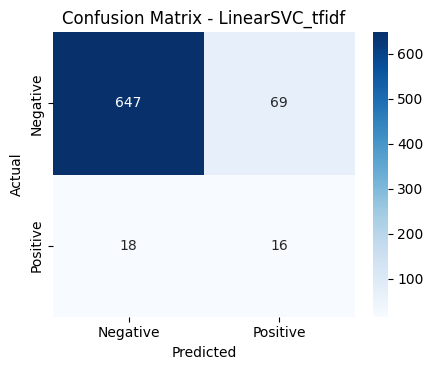


=== MultinomialNB_tfidf ===
Accuracy:    0.8627
Precision:   0.1443
Recall:      0.4118
F1 (binary): 0.2137
F1 (macro):  0.5693

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.92       716
           1       0.14      0.41      0.21        34

    accuracy                           0.86       750
   macro avg       0.56      0.65      0.57       750
weighted avg       0.93      0.86      0.89       750



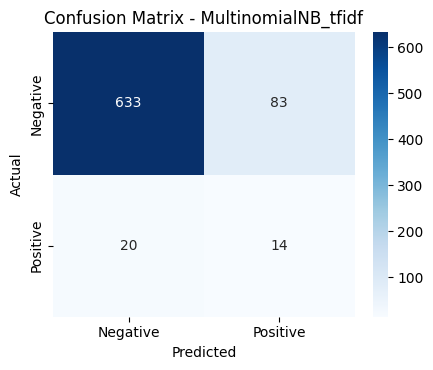


=== RidgeClassifier_tfidf ===
Accuracy:    0.8653
Precision:   0.1546
Recall:      0.4412
F1 (binary): 0.2290
F1 (macro):  0.5776

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.89      0.93       716
           1       0.15      0.44      0.23        34

    accuracy                           0.87       750
   macro avg       0.56      0.66      0.58       750
weighted avg       0.93      0.87      0.89       750



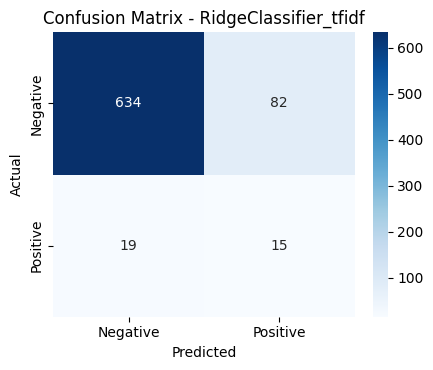


=== PassiveAggressive_tfidf ===
Accuracy:    0.8853
Precision:   0.1750
Recall:      0.4118
F1 (binary): 0.2456
F1 (macro):  0.5918

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.91      0.94       716
           1       0.17      0.41      0.25        34

    accuracy                           0.89       750
   macro avg       0.57      0.66      0.59       750
weighted avg       0.93      0.89      0.91       750



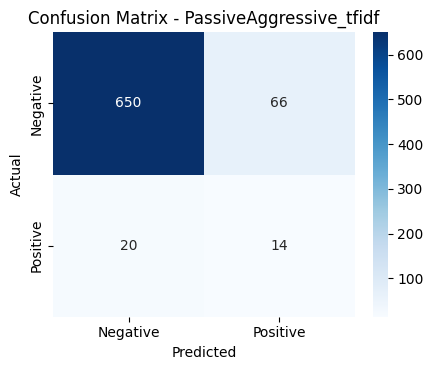


=== LogisticRegression_bow ===
Accuracy:    0.8840
Precision:   0.2211
Recall:      0.6176
F1 (binary): 0.3256
F1 (macro):  0.6311

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.90      0.94       716
           1       0.22      0.62      0.33        34

    accuracy                           0.88       750
   macro avg       0.60      0.76      0.63       750
weighted avg       0.95      0.88      0.91       750



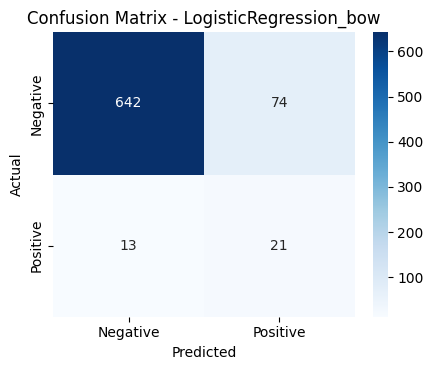


=== LinearSVC_bow ===
Accuracy:    0.8973
Precision:   0.2410
Recall:      0.5882
F1 (binary): 0.3419
F1 (macro):  0.6431

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.91      0.94       716
           1       0.24      0.59      0.34        34

    accuracy                           0.90       750
   macro avg       0.61      0.75      0.64       750
weighted avg       0.95      0.90      0.92       750



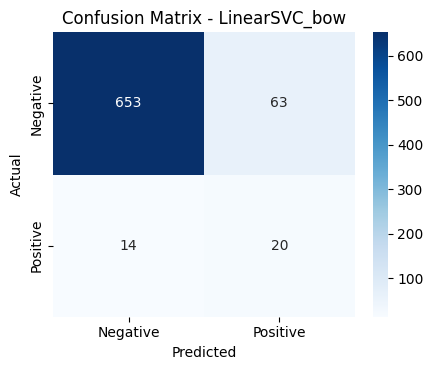


=== MultinomialNB_bow ===
Accuracy:    0.8987
Precision:   0.1912
Recall:      0.3824
F1 (binary): 0.2549
F1 (macro):  0.6003

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.92      0.95       716
           1       0.19      0.38      0.25        34

    accuracy                           0.90       750
   macro avg       0.58      0.65      0.60       750
weighted avg       0.93      0.90      0.91       750



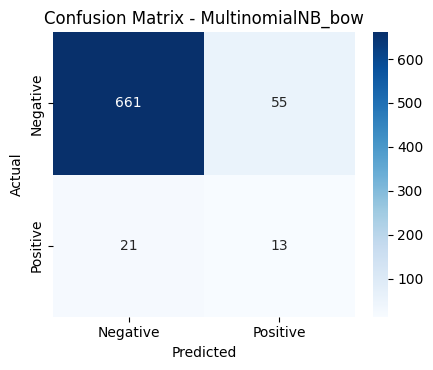


=== RidgeClassifier_bow ===
Accuracy:    0.7613
Precision:   0.1282
Recall:      0.7353
F1 (binary): 0.2183
F1 (macro):  0.5388

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.76      0.86       716
           1       0.13      0.74      0.22        34

    accuracy                           0.76       750
   macro avg       0.56      0.75      0.54       750
weighted avg       0.94      0.76      0.83       750



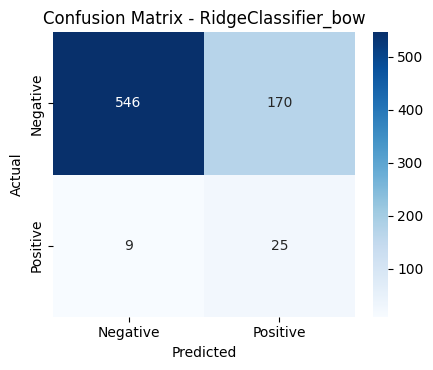


=== PassiveAggressive_bow ===
Accuracy:    0.8960
Precision:   0.2317
Recall:      0.5588
F1 (binary): 0.3276
F1 (macro):  0.6356

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.91      0.94       716
           1       0.23      0.56      0.33        34

    accuracy                           0.90       750
   macro avg       0.60      0.74      0.64       750
weighted avg       0.94      0.90      0.92       750



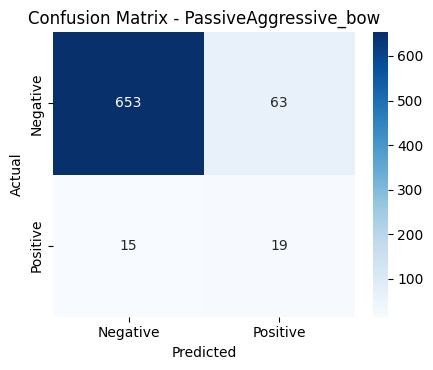

In [49]:
# === Cell 8: EVALUATION OF ALL MODELS (with Confusion Matrix Plot) ===
eval_results = []

for name, preds in val_predictions.items():
    acc = accuracy_score(y_val, preds)
    prec = precision_score(y_val, preds, zero_division=0)
    rec = recall_score(y_val, preds, zero_division=0)
    f1 = f1_score(y_val, preds, zero_division=0)
    f1_macro = f1_score(y_val, preds, average='macro', zero_division=0)
    cm = confusion_matrix(y_val, preds)

    print(f"\n=== {name} ===")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Precision:   {prec:.4f}")
    print(f"Recall:      {rec:.4f}")
    print(f"F1 (binary): {f1:.4f}")
    print(f"F1 (macro):  {f1_macro:.4f}")
    print("\nClassification Report:\n", classification_report(y_val, preds, zero_division=0))

    # ---- Improved Confusion Matrix ----
    plt.figure(figsize=(4.5, 3.8))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    # -----------------------------------

    eval_results.append({
        'model': name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_binary': f1,
        'f1_macro': f1_macro
    })

# **9. Picking the best Model**

# **10. XAI SHAP on Classical Models**

# **11. Deep Learning**

In [ ]:
# Training LSTM / CNN (use GPU runtime in Colab)

# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
# from tensorflow.keras.callbacks import EarlyStopping
# tokenizer = Tokenizer(num_words=20000, oov_token='<OOV>')
# tokenizer.fit_on_texts(X_train)
# X_tr_seq = tokenizer.texts_to_sequences(X_train)
# X_val_seq = tokenizer.texts_to_sequences(X_val)
# X_test_seq = tokenizer.texts_to_sequences(X_test)
# maxlen=200
# X_tr_pad = pad_sequences(X_tr_seq, maxlen=maxlen)
# X_val_pad = pad_sequences(X_val_seq, maxlen=maxlen)
# model = Sequential([
#     Embedding(20000, 128, input_length=maxlen),
#     LSTM(128),
#     Dropout(0.5),
#     Dense(1, activation='sigmoid')
# ])
# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# model.fit(X_tr_pad, y_train, validation_data=(X_val_pad, y_val), epochs=5, batch_size=64)

# **XAI SHAP for LSTM**

# **XAI SHAP for DistilBERT**